In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam

In [2]:
def import_dataset(asset='gc1', format='min'):
    file_path = f'../Data/{asset}{format}.txt'
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.lower()
    df = df.rename(columns={
        'vol': 'volume'
    })
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d')
    # Asegurar que time tenga 6 dígitos (HHMMSS) y convertir a tipo time
    df['time'] = df['time'].astype(str).str.zfill(6)
    df['time'] = pd.to_datetime(df['time'], format='%H%M%S').dt.time
    # Unir fecha y hora en una sola columna de tipo datetime
    df['datetime'] = pd.to_datetime(df['dtyyyymmdd'].astype(str) + ' ' + df['time'].astype(str))
    df = df.sort_values('datetime')
    print(f"Dataset '{asset}' imported with {len(df)} rows")
    specs = pd.read_json("../Data/futuros_specs.json")
    spec = specs[asset[:2].upper()]
    return df, spec

In [3]:
df_min, spec = import_dataset()

Dataset 'gc1' imported with 4565856 rows


In [4]:
def clean(df, asset='gc1'):
    df = df.copy()
    # 1. Eliminar Sábados (Día 5) - Ruido absoluto detectado en el EDA
    df = df[df['datetime'].dt.weekday != 5]
    # 2. Definir el inicio de la sesión (Trading Day)
    # En tus datos el hueco es de 00:00 a 01:00. 
    # Restamos 1 hora para que la vela de la 01:05 sea la primera del "día"
    df['trading_date'] = (df['datetime'] - pd.Timedelta(hours=1)).dt.date
    # 3. Filtrar el ruido del "Break" (15 min antes y 5 min después)
    # Minutos totales del día:
    minutes = df['datetime'].dt.hour * 60 + df['datetime'].dt.minute
    # Filtramos: antes de las 00:00 (cierre) y justo al abrir (01:00)
    # Esto elimina spreads gigantes que la LSTM no puede predecir
    mask_noise = (minutes >= 1425) | (minutes == 60) 
    df = df[~mask_noise]
    # 4. Eliminar duplicados y asegurar orden temporal
    df = df.drop_duplicates(subset=['datetime']).sort_values('datetime')
    # 5. Resetear índice para que la secuencia de la LSTM sea continua
    df = df.reset_index(drop=True)
    print(f"Limpieza {asset} completada. Filas restantes: {len(df)}")
    return df

In [5]:
df_min_clean = clean(df_min)

Limpieza gc1 completada. Filas restantes: 4518540


In [6]:
def resample_ohlcv(df, period="5min"):
    """
    Resamplea un dataframe OHLCV al periodo deseado.
    period puede ser: '1min', '5min', '15min', '30min', '1H', '1D', etc.
    """

    # Asegurar orden temporal
    df = df.sort_values("datetime").copy()

    # Asegurar que datetime es datetime64
    df["datetime"] = pd.to_datetime(df["datetime"])

    # Establecer índice temporal
    df = df.set_index("datetime")

    # Diccionario OHLCV estándar
    ohlc_dict = {
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum",
        "openint": "last"
    }

    # Resample usando el periodo elegido
    df_resampled = df.resample(period).agg(ohlc_dict)

    # Eliminar velas vacías
    df_resampled = df_resampled.dropna(subset=["open", "high", "low", "close"])

    # Añadir columnas extra
    df_resampled["ticker"] = df["ticker"].iloc[0]
    df_resampled["per"] = period

    # Reset index
    df_resampled = df_resampled.reset_index()

    return df_resampled

In [7]:
df_min_clean_5min = resample_ohlcv(df_min_clean, period="30min")

In [8]:
def daily_ohlcv_cummulative(df_5_min):
    df = df_5_min.copy()
    df = df.sort_values('datetime')
    # Usamos el desplazamiento de 1 hora que definimos en la limpieza
    df['trading_date'] = (df['datetime'] - pd.Timedelta(hours=1)).dt.date
    
    # Ahora agrupamos por 'trading_date' en lugar de 'date'
    df['open_day'] = df.groupby('trading_date')['open'].transform('first')
    df['high_cum'] = df.groupby('trading_date')['high'].cummax()
    df['low_cum'] = df.groupby('trading_date')['low'].cummin()
    df['volume_cum'] = df.groupby('trading_date')['volume'].cumsum()
    
    return df


In [9]:
df_min_clean_5min_with_cum = daily_ohlcv_cummulative(df_min_clean_5min)

In [10]:
df_min_clean_5min_with_cum.loc[1]

datetime        2010-09-20 07:30:00
open                         1280.8
high                         1283.4
low                          1280.7
close                        1282.3
volume                         1492
openint                         0.0
ticker                           GC
per                           30min
trading_date             2010-09-20
open_day                     1279.8
high_cum                     1283.4
low_cum                      1279.8
volume_cum                     1710
Name: 1, dtype: object

In [11]:
def add_time_features(df):
    """
    Optimizada para 30 minutos: Elimina redundancias y añade el día de la semana,
    crucial para los futuros del Oro.
    """
    df = df.copy()
    
    # ---------------------------------------------------------
    # 1. CICLO INTRADIARIO (48 bloques de 30 min)
    # ---------------------------------------------------------
    # Sustituye a la hora. Un solo ciclo de 48 pasos es perfecto para la LSTM.
    step_30m = (df['datetime'].dt.hour * 2) + (df['datetime'].dt.minute // 30)
    df['step_sin'] = np.sin(2 * np.pi * step_30m / 48)
    df['step_cos'] = np.cos(2 * np.pi * step_30m / 48)

    # ---------------------------------------------------------
    # 2. CICLO SEMANAL (NUEVO)
    # ---------------------------------------------------------
    # El Oro se comporta diferente los lunes (gaps del finde) y viernes (cierres)
    day_of_week = df['datetime'].dt.dayofweek # Lunes=0, Domingo=6
    df['dow_sin'] = np.sin(2 * np.pi * day_of_week / 7)
    df['dow_cos'] = np.cos(2 * np.pi * day_of_week / 7)

    # ---------------------------------------------------------
    # 3. SESIONES INSTITUCIONALES (Basado en UTC/GMT)
    # ---------------------------------------------------------
    # NOTA: Ajusta estos horarios si tus datos tienen otro Timezone (ej. EST)
    df['is_london'] = df['datetime'].dt.hour.isin(range(8, 17)).astype(int)
    df['is_ny'] = df['datetime'].dt.hour.isin(range(13, 22)).astype(int)
    df['is_overlap'] = ((df['is_london'] == 1) & (df['is_ny'] == 1)).astype(int)

    return df

In [12]:
def add_tick_features(df, tick_size=0.1): # El tick size del GC suele ser 0.1
    df = df.copy()
    
    # ---------------------------------------------------------
    # 1. MICRO-ESTRUCTURA: Ticks Absolutos (Mantenidos)
    # ---------------------------------------------------------
    df['body_ticks'] = (df['close'] - df['open']) / tick_size
    df['range_ticks'] = (df['high'] - df['low']) / tick_size
    df['upper_wick_ticks'] = (df['high'] - df[['open', 'close']].max(axis=1)) / tick_size
    df['lower_wick_ticks'] = (df[['open', 'close']].min(axis=1) - df['low']) / tick_size
    
    # ---------------------------------------------------------
    # 2. MICRO-ESTRUCTURA: Proporciones (NUEVO)
    # ---------------------------------------------------------
    # Usamos 1e-8 para evitar divisiones por cero en dojis perfectos
    df['body_pct'] = abs(df['body_ticks']) / (df['range_ticks'] + 1e-8)
    df['upper_wick_pct'] = df['upper_wick_ticks'] / (df['range_ticks'] + 1e-8)
    df['lower_wick_pct'] = df['lower_wick_ticks'] / (df['range_ticks'] + 1e-8)
    
    # Dónde cierra la vela: 1 = En el máximo (Bullish max), 0 = En el mínimo (Bearish max)
    df['close_location'] = (df['close'] - df['low']) / ((df['high'] - df['low']) + 1e-8)
    
    # ---------------------------------------------------------
    # 3. MACRO-CONTEXTO DEL DÍA (Mantenidos)
    # ---------------------------------------------------------
    df['dist_high_cum_ticks'] = (df['high_cum'] - df['close']) / tick_size
    df['dist_low_cum_ticks'] = (df['close'] - df['low_cum']) / tick_size
    df['dist_open_day_ticks'] = (df['close'] - df['open_day']) / tick_size
    
    # ---------------------------------------------------------
    # 4. DINÁMICAS DE VOLUMEN (Modificados / NUEVO)
    # ---------------------------------------------------------
    # Esfuerzo por tick de rango total (liquidez de la vela)
    df['vol_per_tick'] = df['volume'] / (df['range_ticks'] + 1)
    
    # Esfuerzo vs Resultado Direccional: Volumen usado para mover el precio netamente (cuerpo)
    # Si hay mucho volumen y poco cuerpo, indica posible absorción o freno.
    df['vol_vs_body'] = df['volume'] / (abs(df['body_ticks']) + 1)
    
    # Porcentaje de participación: Qué peso tiene esta vela en el día actual
    df['vol_weight_intraday'] = df['volume'] / (df['volume_cum'] + 1)
    
    return df

In [13]:
def add_indicator_features(df, tick_size=0.1):
    df = df.copy()
    
    # Log returns de la vela actual (Momentum base)
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
    
    # ---------------------------------------------------------
    # 1. TARGETS CORREGIDOS (Para DF de 30 minutos)
    # ---------------------------------------------------------
    # Shift(-1) = Próximos 30 min | Shift(-2) = Próximos 60 min
    df['target_ret_30m'] = np.log(df['close'].shift(-1) / df['close'])
    df['target_ret_1h'] = np.log(df['close'].shift(-2) / df['close'])

    # ---------------------------------------------------------
    # 2. INDICADORES DE MOMENTUM Y TENDENCIA
    # ---------------------------------------------------------
    # RSI de 14 periodos (Cálculo real de Wilder usando EWM)
    delta = df['close'].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    # com=13 es el equivalente a la media suavizada de 14 periodos de Wilder
    avg_gain = gain.ewm(com=13, adjust=False).mean()
    avg_loss = loss.ewm(com=13, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-8) # Evitar división por cero
    df['rsi_14'] = 100 - (100 / (1 + rs))
    
    # Distancia a la Media Móvil (SMA 20 -> 10 horas de trading en 30m)
    df['sma_20'] = df['close'].rolling(window=20).mean()
    df['dist_sma_20_ticks'] = (df['close'] - df['sma_20']) / tick_size
    
    # NUEVO: Volatilidad (Proxy de ATR / Desviación Estándar)
    # Vital para que la LSTM sepa si el mercado está rápido o lento
    df['volatility_20'] = df['log_ret'].rolling(window=20).std()
    
    # Limpieza de columnas temporales de cálculo
    df.drop(['sma_20'], axis=1, inplace=True, errors='ignore')
    
    return df

In [14]:
def generate_features(df, spec):
    df = df.copy()
    
    # 1. Tiempo
    df = add_time_features(df)
    
    # 2. Ticks (usando tu spec)
    df = add_tick_features(df, spec['tick_size'])
    
    # 3. Indicadores
    df = add_indicator_features(df)
    
    # 4. Limpieza final de NaNs (creados por las medias móviles)
    df = df.dropna()
    
    return df


In [15]:
df_features = generate_features(df_min_clean_5min_with_cum, spec)

In [16]:
df_features.iloc[0]

datetime               2010-09-20 17:00:00
open                                1279.6
high                                1283.9
low                                 1279.4
close                               1282.9
volume                                6861
openint                                0.0
ticker                                  GC
per                                  30min
trading_date                    2010-09-20
open_day                            1279.8
high_cum                            1284.9
low_cum                             1278.3
volume_cum                           35188
step_sin                         -0.965926
step_cos                         -0.258819
dow_sin                                0.0
dow_cos                                1.0
is_london                                0
is_ny                                    1
is_overlap                               0
body_ticks                            33.0
range_ticks                           45.0
upper_wick_

In [17]:
def final_cleanup(df):
    # Columnas que NO deben ir al modelo (solo sirven para tracking)
    drop_cols = [
        'datetime', 'ticker', 'per', 'trading_date', 
        'open', 'high', 'low', 'close', 'volume', # Usamos sus versiones en ticks/logs
        'open_day', 'high_cum', 'low_cum', 'volume_cum', # Usamos sus distancias
        'openint' # Está a 0 siempre
    ]
    
    # 1. Eliminar lo innecesario
    df_clean = df.drop(columns=drop_cols, errors='ignore')
    
    # 2. Manejo de infinitos (por si acaso en las divisiones de volumen)
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    
    # 3. DROP NA (Aquí es donde limpias los bordes de los indicadores y targets)
    df_clean = df_clean.dropna()
    
    return df_clean

In [18]:
# df_model = final_cleanup(df_features)
df_model = df_features.copy()

In [19]:
def prepare_classification_targets(df, threshold_ticks=5, tick_size=0.1):
    """
    Convierte retornos logarítmicos en clases:
    0: Sell (Caída > threshold)
    1: Neutral (Rango lateral)
    2: Buy (Subida > threshold)
    """
    # Calculamos el movimiento en ticks
    # (precio_futuro - precio_actual) / tick_size
    future_move_ticks = (np.exp(df['target_ret_30m']) - 1) * df['close'] / tick_size
    
    conditions = [
        (future_move_ticks <= -threshold_ticks), # Sell
        (future_move_ticks >= threshold_ticks)   # Buy
    ]
    choices = [0, 2] # 0=Sell, 2=Buy
    
    df['target_class'] = np.select(conditions, choices, default=1) # 1=Neutral
    return df

# Aplicar antes de crear el dataset
df_model = prepare_classification_targets(df_model, threshold_ticks=10) # 10 ticks = 1 punto en GC

In [20]:
def create_lstm_dataset(df, features, target_col, lookback=14):
    """
    Crea el dataset para LSTM usando NumPy strides (ultra rápido).
    """
    # 1. Convertimos a NumPy array (importante para velocidad)
    feature_array = df[features].values
    target_array = df[target_col].values
    
    # 2. Calculamos las dimensiones
    num_samples = len(df) - lookback
    num_features = len(features)
    
    # 3. Magia de NumPy Strides: Creamos ventanas sin bucles
    # (samples, lookback, features)
    shape = (num_samples, lookback, num_features)
    strides = (feature_array.strides[0], feature_array.strides[0], feature_array.strides[1])
    
    X = np.lib.stride_tricks.as_strided(feature_array, shape=shape, strides=strides)
    
    # 4. El target es simplemente el valor DESPUÉS de la ventana
    y = target_array[lookback:]
    
    return X, y

In [21]:
# Definir las columnas finales que vimos en el paso anterior
feature_cols = [
    'step_sin', 'step_cos', 'dow_sin', 'dow_cos', 'is_london', 'is_ny', 'is_overlap',
    'body_pct', 'upper_wick_pct', 'lower_wick_pct', 'close_location',
    'dist_high_cum_ticks', 'dist_low_cum_ticks', 'dist_open_day_ticks',
    'vol_per_tick', 'vol_vs_body', 'vol_weight_intraday', 'rsi_14', 'volatility_20'
]

# Escalar
scaler = StandardScaler()
df_model[feature_cols] = scaler.fit_transform(df_model[feature_cols])

# Crear X, y
X, y = create_lstm_dataset(df_model, feature_cols, 'target_class', lookback=14)

def build_lstm_model_30m(input_shape):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True), # Más neuronas para 30m
        BatchNormalization(),
        Dropout(0.3),
        
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(32, activation='relu'),
        Dense(3, activation='softmax') 
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.0005), # LR más bajo para mayor estabilidad
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [24]:
# CONFIGURACIÓN OPTIMIZADA PARA ORO 30M (14 AÑOS DE DATOS)
train_size = 50000  # ~2 años de memoria para la LSTM (Aprende ciclos largos)
test_size = 25000    # ~5-6 meses de evaluación por cada run
step = 25000         # Sin solapamiento ni huecos: evaluamos TODO el histórico linealmente
all_predictions = []

for start in range(0, len(X) - train_size - test_size, step):
    end_train = start + train_size
    end_test = end_train + test_size
    
    X_train_wf, y_train_wf = X[start:end_train], y[start:end_train]
    X_test_wf, y_test_wf = X[end_train:end_test], y[end_train:end_test]
    
    # Re-instanciamos el modelo para evitar "memoria" entre ventanas
    model = build_lstm_model_30m((X.shape[1], X.shape[2]))
    
    # EarlyStopping para no sobre-entrenar (crucial en series temporales)
    from tensorflow.keras.callbacks import EarlyStopping
    es = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    
    model.fit(X_train_wf, y_train_wf, epochs=20, batch_size=128, verbose=1, callbacks=[es]) 
    
    preds = model.predict(X_test_wf)
    # Justo después de: pred_classes = np.argmax(preds, axis=1)
    pred_classes = np.argmax(preds, axis=1)
    print(f"Distribución de predicciones: {np.bincount(pred_classes, minlength=3)}")
    print(f"Distribución real: {np.bincount(y_test_wf, minlength=3)}")
    # Guardar resultados...
    # (Tu código de guardado está perfecto)
    window_results = pd.DataFrame({
        'actual': y_test_wf,
        'actual_ret': df_model.iloc[end_train:end_test]['target_ret_30m'].values, # <--- AÑADE ESTO
        'pred': pred_classes,
        'prob_sell': preds[:, 0],
        'prob_neutral': preds[:, 1],
        'prob_buy': preds[:, 2]
    })
    
    all_predictions.append(window_results)
    
    print(f"--- Ventana completada y guardada. Total acumuladas: {len(all_predictions)} ---")

# Al final del bucle, une todo en un solo DataFrame
df_results = pd.concat(all_predictions, ignore_index=True)

Epoch 1/20


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.5262 - loss: 1.0131
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5530 - loss: 0.9635
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5541 - loss: 0.9553
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5570 - loss: 0.9499
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5575 - loss: 0.9458
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5600 - loss: 0.9431
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5606 - loss: 0.9426
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5614 - loss: 0.9384
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5612 - loss: 0.9380
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5640 - loss: 0.9356
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5623 - loss: 0.9338
Epoch 12/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/st

In [25]:
import matplotlib.pyplot as plt

def evaluate_results(all_predictions):
    # 1. Unimos todos los resultados de las ventanas
    results = pd.concat(all_predictions, ignore_index=True)
    
    # 2. Métrica de precisión simple
    accuracy = (results['actual'] == results['pred']).mean()
    print(f"Accuracy Global: {accuracy:.2%}")
    
    # 3. Simulación de P&L Teórico (muy simplificada)
    # Asignamos: Buy (+1), Sell (-1), Neutral (0)
    # Nota: Esto es una aproximación, lo ideal sería usar el log_ret real
    def calculate_pnl(row):
        if row['pred'] == 2: # Predijo Compra
            if row['actual'] == 2: return 1  # Acierto
            if row['actual'] == 0: return -1 # Error grave (era venta)
            return -0.5 # Error leve (era lateral)
        if row['pred'] == 0: # Predijo Venta
            if row['actual'] == 0: return 1 
            if row['actual'] == 2: return -1
            return -0.5
        return 0 # Neutral no suma ni resta
    
    results['pnl'] = results.apply(calculate_pnl, axis=1)
    results['equity_curve'] = results['pnl'].cumsum()
    
    # 4. Gráfico de la curva de capital
    plt.figure(figsize=(12, 6))
    plt.plot(results['equity_curve'], label='Curva de Capital Teórica')
    plt.title('Rendimiento Acumulado del Modelo (Walk-Forward)')
    plt.xlabel('Velas de Test (30 min)')
    plt.ylabel('Puntos Acumulados')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return results

# Ejecutar después del bucle:
# final_df = evaluate_results(all_predictions)

Accuracy Global: 59.78%


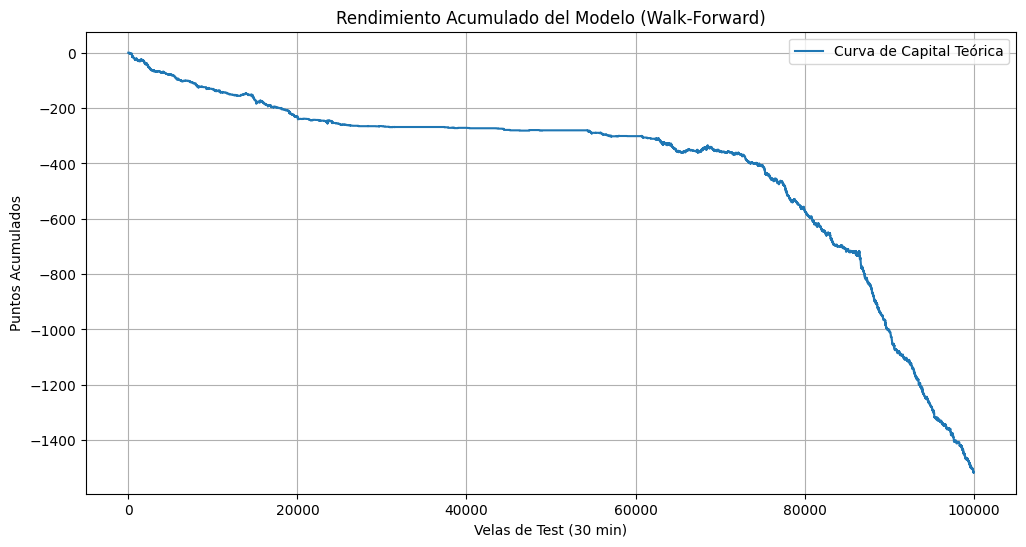

In [26]:
final_df = evaluate_results(all_predictions)

In [27]:


def advanced_trading_eval(all_predictions):
    # 1. Consolidar resultados
    results = pd.concat(all_predictions, ignore_index=True)
    
    # 2. Calcular P&L Realista
    # 0: Sell, 1: Neutral, 2: Buy
    # Asumimos que si predice 2 (Buy), ganamos el retorno de la siguiente vela
    # Si predice 0 (Sell), ganamos el inverso del retorno
    results['trade_return'] = 0.0
    
    # Nota: Aquí usamos target_ret_30m que es el log_ret real del mercado
    # (Asegúrate de haber incluido 'target_ret_30m' en tu dataframe de resultados original)
    # Si no lo tienes, usa esta aproximación con las etiquetas:
    results.loc[results['pred'] == 2, 'trade_return'] = results['actual_ret'] # Ganancia en largos
    results.loc[results['pred'] == 0, 'trade_return'] = -results['actual_ret'] # Ganancia en cortos
    
    # 3. Curva de Capital y Drawdown
    results['equity'] = results['trade_return'].cumsum()
    results['peak'] = results['equity'].cummax()
    results['drawdown'] = results['equity'] - results['peak']
    
    # 4. Visualización Dual
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # Gráfico de Equity
    ax1.plot(results['equity'], color='#2ecc71', lw=2, label='Curva de Capital (Log Returns)')
    ax1.fill_between(range(len(results)), results['equity'], color='#2ecc71', alpha=0.1)
    ax1.set_title('Rendimiento Estratégico LSTM - Futuros Oro (GC)', fontsize=16)
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)
    
    # Gráfico de Drawdown
    ax2.fill_between(range(len(results)), results['drawdown'], 0, color='#e74c3c', alpha=0.5)
    ax2.set_title('Drawdown (Riesgo de Caída)', fontsize=12)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Métricas Clave
    win_rate = (results['trade_return'] > 0).sum() / (results['pred'] != 1).sum()
    profit_factor = results[results['trade_return'] > 0]['trade_return'].sum() / \
                    abs(results[results['trade_return'] < 0]['trade_return'].sum())
    
    print(f"--- REPORTE DE ESTRATEGIA ---")
    print(f"Win Rate (excluyendo Neutral): {win_rate:.2%}")
    print(f"Profit Factor: {profit_factor:.2f}")
    print(f"Máximo Drawdown: {results['drawdown'].min():.4f}")
    
    return results

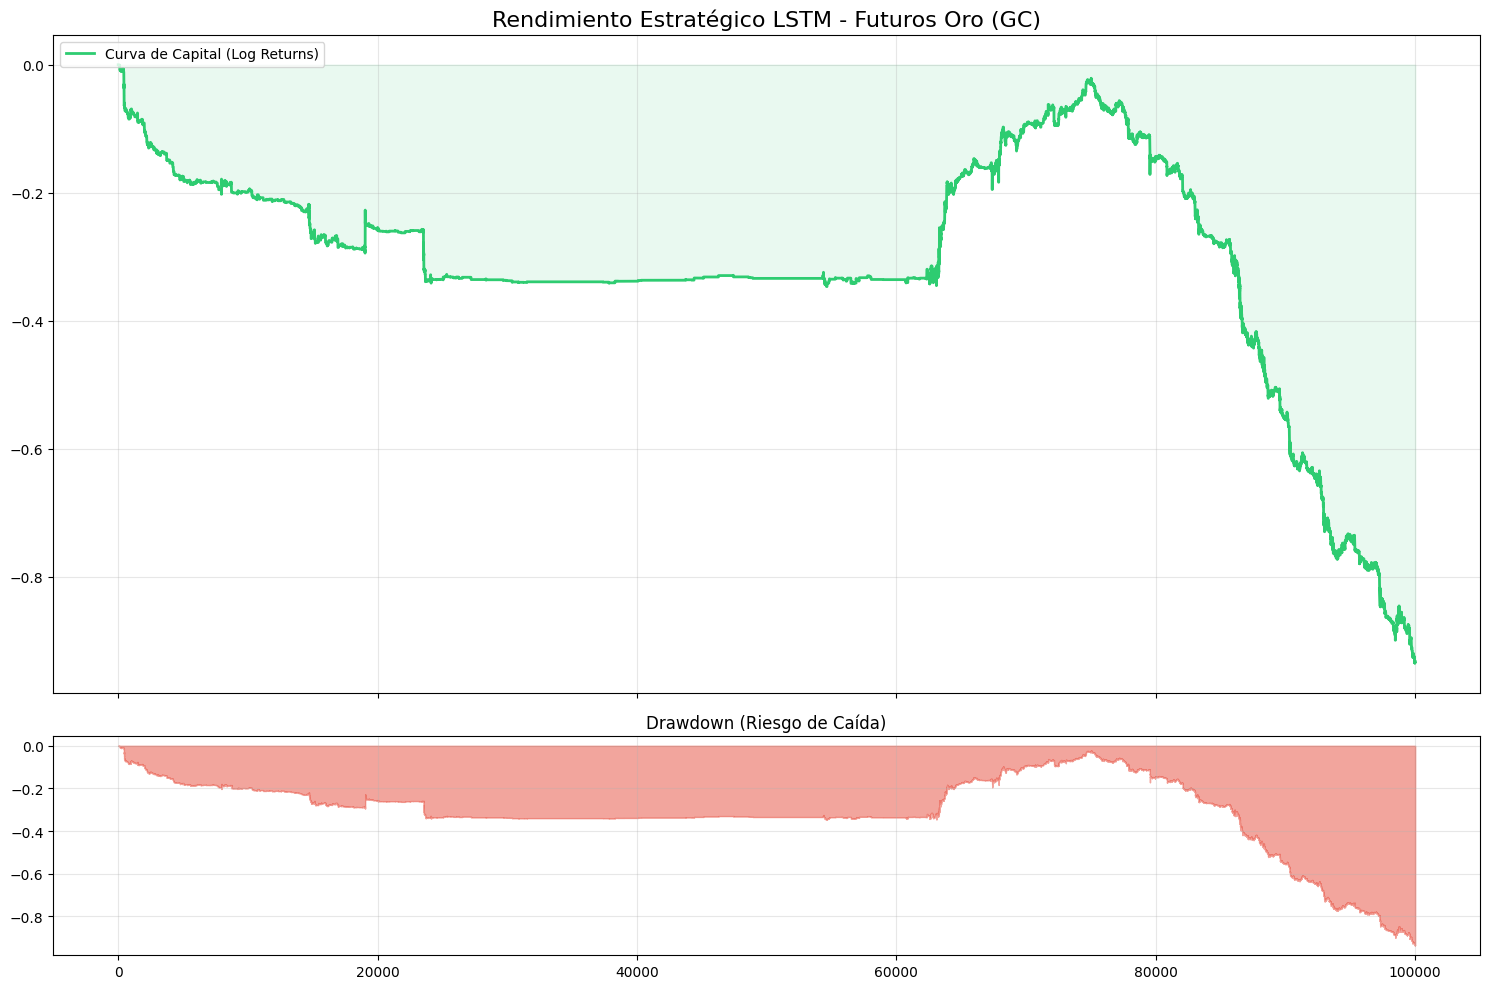

--- REPORTE DE ESTRATEGIA ---
Win Rate (excluyendo Neutral): 46.71%
Profit Factor: 0.86
Máximo Drawdown: -0.9351


In [28]:
results = advanced_trading_eval(all_predictions)